###
<h1><strong>Task 2: Time Series Analysis (TSA)</strong></h1>
<p><strong>Description:</strong>Analyze a time-series dataset (e.g., stock prices, temperature data) to detect trends and seasonality.</p>

<h3><strong> Objectives:</strong></h3> 
<ul>
    <li>Plot time-series data and identify patterns.</li>
    <li>Decompose the series into trend, seasonality, and residuals using statsmodels.</li>
    <li>Perform moving average smoothing and plot the results.</li>
</ul>
<p>Tools: Python, pandas, matplotlib, statsmodels.</p>

In [14]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import statsmodels as sta
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))



CLEAN_DIR = PROJECT_ROOT / "data/cleaned_data"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {PROJECT_ROOT}")
print(f"Cleaned files : {len(list(CLEAN_DIR.rglob('*.csv')))}")

Projet : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis
Cleaned files : 5


<h4>The dataset: Stock prices</h4>
<p>
    <h4><strong><li>Plot time-series data and identify patterns.</li></strong></h4>
</p>

<h3><strong>What i'm going to do is:</strong></h3>
<p>
    <ul>
        <li>Load the dataset</li>
        <li>Pick the symbol (AAPL)</li>
        <li>Convert the date column in temporel index</li>
        <li>Print the series</li>
        <li>Smooth with seasonal_decompose</li>
        <li>Print the four components</li>
        <li>End up with a written conclusion</li>
    </ul>
</p>

<h3> For this task, selecting one stock (AAPL) is better because:</h3>
<p>
<li>easier to visualize</li>
<li>easier to interpret</li>
<li>easier to explain trend and seasonality</li>
<li>matches the objective of a single time-series analysis.</li>
</p>

Dataset for AAPL:
            close_price
date                   
2014-01-02      79.0185
2014-01-03      77.2828
2014-01-04      77.2828
2014-01-05      77.2828
2014-01-06      77.7042

Shape: (1458, 1)


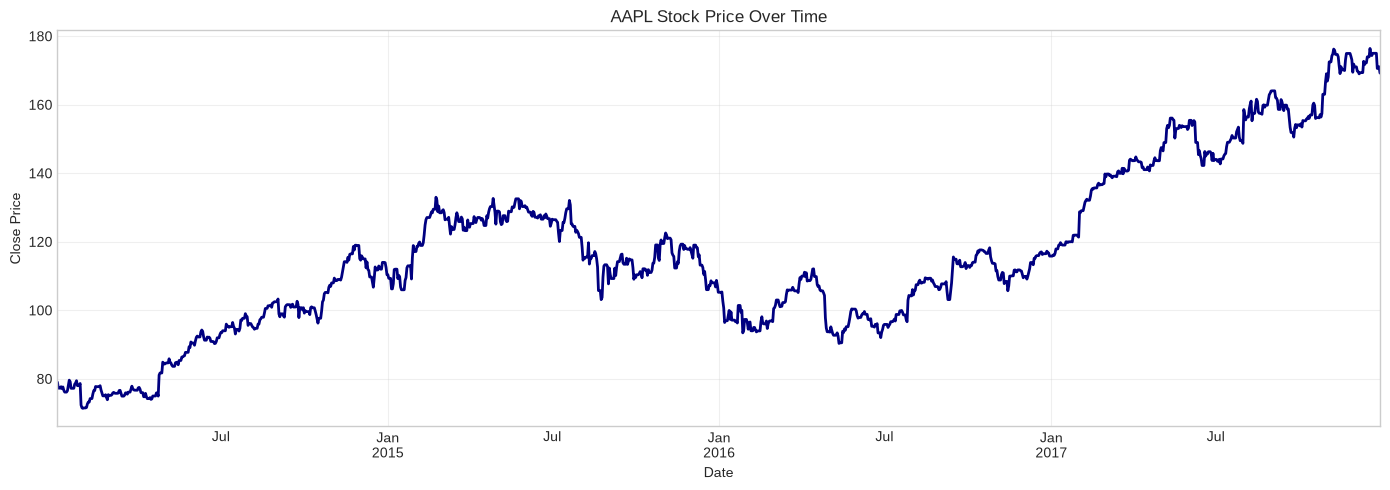

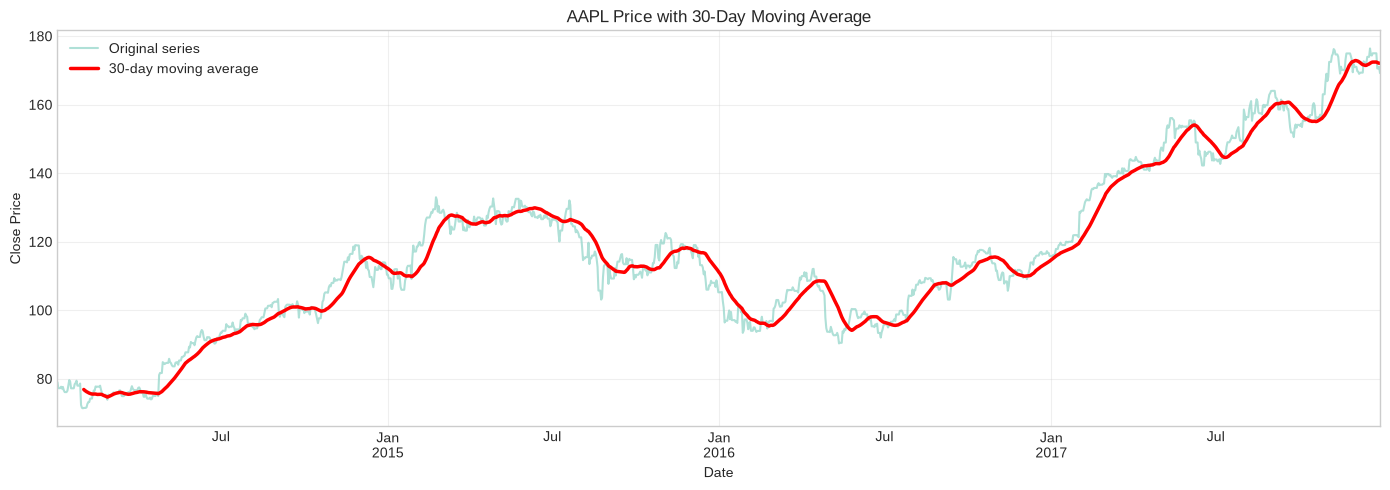

/tmp/ipykernel_10615/267886922.py:72: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  result = seasonal_decompose(


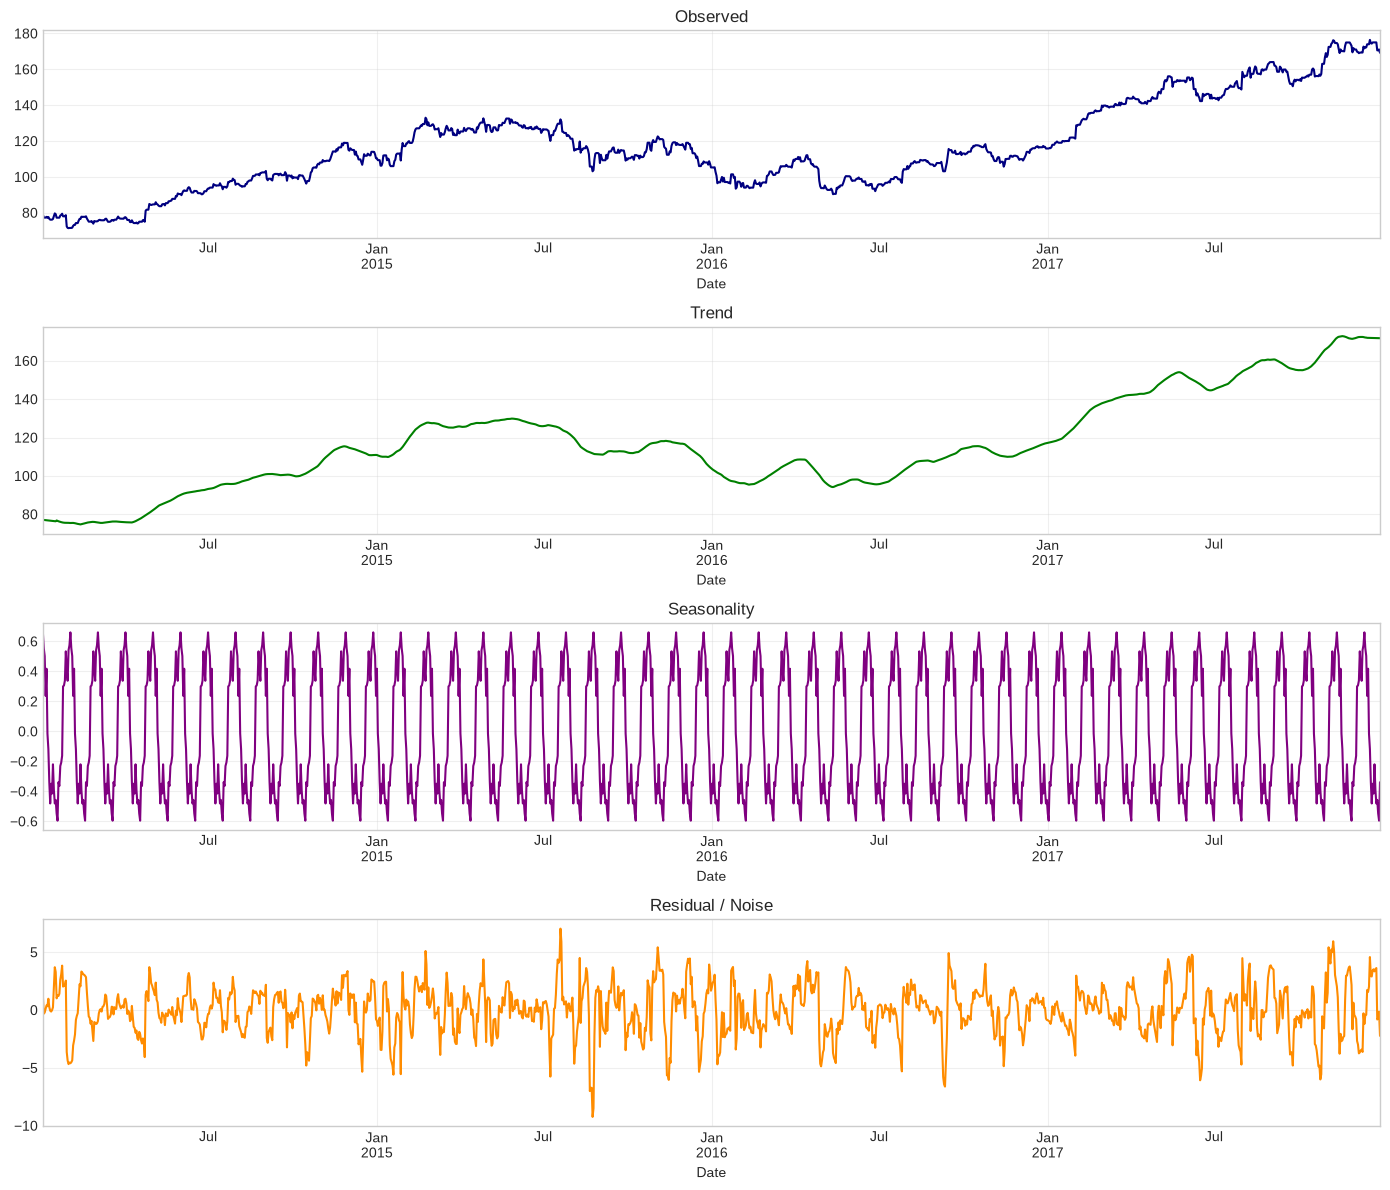


Summary statistics:
count    1458.000000
mean      116.722522
std        24.506909
min        71.397400
25%        98.970000
50%       113.050000
75%       129.080000
max       176.420000
Name: close_price, dtype: float64

Conclusion template:
The AAPL time series shows a visible trend over time, with short-term fluctuations around the general direction. The moving average smooths the noise and helps highlight the long-term pattern. The decomposition separates the observed series into trend, seasonality, and residual components, which allows a clearer interpretation of the data behavior.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --------------------------------------------------
# Task 2: Time Series Analysis (TSA)
# Explicit code to respond to the notebook tasks
# --------------------------------------------------

# 1. We load the time-series dataset
# The file contains stock data for multiple symbols; we select one stock (AAPL)
df = pd.read_csv(CLEAN_DIR/'c_stock.csv', parse_dates=['date'])
df = df.sort_values('date')

# We keep only one symbol to make the time series easier to interpret
symbol = 'AAPL'
stock = df[df['symbol'] == symbol][['date', 'close']].copy()
stock = stock.rename(columns={'close': 'close_price'})
stock = stock.set_index('date')

# We fill missing values if any
stock = stock.asfreq('D')
stock['close_price'] = stock['close_price'].ffill().bfill()

print(f"Dataset for {symbol}:")
print(stock.head())
print('\nShape:', stock.shape)

# --------------------------------------------------
# Objective 1: Plot time-series data and identify patterns
# --------------------------------------------------
plt.figure(figsize=(14, 5))
stock['close_price'].plot(color='navy', linewidth=2)
plt.title(f'{symbol} Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation note:
# - If the curve rises steadily, the series has a positive trend.
# - If it oscillates regularly, there may be seasonality or cycles.
# - Sudden spikes indicate volatility or anomalies.

# --------------------------------------------------
# Objective 2: We smooth the series using moving average
# --------------------------------------------------
window = 30
stock['moving_avg_30'] = stock['close_price'].rolling(window=window).mean()

plt.figure(figsize=(14, 5))
stock['close_price'].plot(label='Original series', alpha=0.7)
stock['moving_avg_30'].plot(label=f'{window}-day moving average', linewidth=2.5, color='red')
plt.title(f'{symbol} Price with {window}-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation note:
# - The moving average smooths short-term fluctuations.
# - It makes the general trend easier to detect.

# --------------------------------------------------
# Objective 3: We decompose into trend, seasonality and residuals
# --------------------------------------------------
# We choose a period for the seasonal cycle.
# For daily stock data, 30 is a practical monthly window.
result = seasonal_decompose(
    stock['close_price'],
    model='additive',
    period=30,
    extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
result.observed.plot(ax=axes[0], title='Observed', color='navy')
result.trend.plot(ax=axes[1], title='Trend', color='green')
result.seasonal.plot(ax=axes[2], title='Seasonality', color='purple')
result.resid.plot(ax=axes[3], title='Residual / Noise', color='darkorange')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

# Print key statistics
print('\nSummary statistics:')
print(stock['close_price'].describe())

# Interpretation note:
# - Trend: long-term movement of the data.
# - Seasonality: repeating pattern within a fixed time period.
# - Residual: random component left after removing trend and seasonality.

# --------------------------------------------------
# Final conclusion template for the report
# --------------------------------------------------
print('\nConclusion template:')
print(f"The {symbol} time series shows a visible trend over time, with short-term fluctuations around the general direction. "
      "The moving average smooths the noise and helps highlight the long-term pattern. "
      "The decomposition separates the observed series into trend, seasonality, and residual components, "
      "which allows a clearer interpretation of the data behavior.")
